# Combined Pipeline — All Notebooks

This notebook merges notebooks 01–09 into a single, runnable pipeline.

**Table of Contents:**

1. Notebook 01 — Index the ToolBench API Corpus
2. Notebook 02 — Full-Corpus Baseline Evaluation
3. Notebook 03 — Hard-Negative Ablation
4. Notebook 04 — Baseline Analysis and Ablations
5. Notebook 05 — Contrastive Fine-Tuning
6. Notebook 06 — Fine-Tuned Model Evaluation
7. Notebook 07 — Hierarchical Contrastive Training
8. Notebook 08 — Tri-Modal Training
9. Notebook 09 — Final Evaluation and Analysis

## Shared Setup

Run this cell once before any other section.

In [ ]:
!pip install sentence-transformers faiss-cpu openai python-dotenv tqdm scikit-learn matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 89.0 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
from pathlib import Path

os.environ["OPENAI_API_KEY"] = "ur_open_ai_key"
os.environ["TOOLBENCH_DIR"] = "/content/drive/MyDrive/data"

In [ ]:
!git clone https://github.com/arthurdls/multimodal-tool-retrieval.git /content/repo


Cloning into '/content/repo'...
remote: Enumerating objects: 86, done.
remote: Counting objects: 100% (86/86), done.
remote: Compressing objects: 100% (56/56), done.
remote: Total 86 (delta 42), reused 70 (delta 28), pack-reused 0 (from 0)
Receiving objects: 100% (86/86), 82.75 KiB | 16.55 MiB/s, done.
Resolving deltas: 100% (42/42), done.


In [ ]:
# ============================================================
# SHARED SETUP — Run this cell first
# ============================================================
import os, sys, json, random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from dotenv import load_dotenv
from tqdm import tqdm

REPO_ROOT = Path("/content/repo")
PROJECT_DIR = REPO_ROOT / "project"
(PROJECT_DIR / "checkpoints").mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(PROJECT_DIR))

TOOLBENCH_DIR = Path(os.environ["TOOLBENCH_DIR"])

print(f"Repo:      {REPO_ROOT}")
print(f"Project:   {PROJECT_DIR}")
print(f"Toolbench: {TOOLBENCH_DIR}")


Repo:      /content/repo
Project:   /content/repo/project
Toolbench: /content/drive/MyDrive/data


In [ ]:
os.environ["TOOLBENCH_DIR"] = "/content/drive/MyDrive/Data"


In [ ]:
import os
print(os.listdir("/content/drive/MyDrive/data/"))

['toolllama_G123_dfs_eval.json', 'toolllama_G123_dfs_train.json', '.DS_Store', 'toolenv', 'processed', 'instruction', 'test_query_ids', 'retrieval_test_query_ids', 'retrieval', 'test_instruction', 'answer']


---

# Notebook 01 — Index the ToolBench API Corpus

## Setup

## Load the API Corpus

ToolBench organizes APIs hierarchically: **Category → Tool → Endpoint**. We flatten this into a list of individual API entries, each with name, description, category, tool name, and parameters.

In [ ]:
from data.load_toolbench import load_api_corpus
from models.embeddings import format_api_string, get_embeddings
import numpy as np
from tqdm import tqdm

corpus = load_api_corpus(TOOLBENCH_DIR / "toolenv" / "tools")
print(f"Loaded {len(corpus)} APIs across {len(set(a['category'] for a in corpus))} categories")

Loaded 4518 APIs across 32 categories


## Embed All APIs

Each API is formatted as a structured string:
```
[category] > [tool_name]: [name] — [description] | Parameters: [param1, param2, ...]
```
This format preserves the hierarchical structure and parameter information in a single text representation suitable for embedding.

In [ ]:
api_strings = [format_api_string(a) for a in corpus]
print("Sample:", api_strings[0])

# Embed all APIs (cached — safe to re-run)
BATCH = 500
all_embeddings = []
for i in tqdm(range(0, len(api_strings), BATCH)):
    batch = api_strings[i:i+BATCH]
    embs = get_embeddings(batch)
    all_embeddings.append(embs)

corpus_matrix = np.vstack(all_embeddings)
np.save(PROJECT_DIR / "corpus_embeddings.npy", corpus_matrix)
print(f"Saved corpus_embeddings.npy: shape {corpus_matrix.shape}")

Sample: Artificial_Intelligence_Machine_Learning > Object Detection: Detect — Detect objects present in the photo, if there is 10 of thing X, the X thing will repeat 10 times in the result, each X has their bounding box(4 coordinations), the photo param is your jpg photo base64 encoded, the minscore is the minimum score you would like to get, it is between 0 & 1, the maximum number of detections is 100 | Parameters: photo, minscore


100%|██████████| 10/10 [00:35<00:00,  3.54s/it]

Saved corpus_embeddings.npy: shape (4518, 1536)


## Save API Name Index

Save the ordered list of API action names so downstream notebooks can map embedding indices back to API identities.

In [ ]:
import json
api_names = [a["action_name"] for a in corpus]
with open(PROJECT_DIR / "api_names.json", "w") as f:
    json.dump(api_names, f)
print(f"Saved {len(api_names)} API names")

Saved 4518 API names


---

# Notebook 02 — Full-Corpus Baseline Evaluation

## Setup

## Load Data

Load the pre-computed API embeddings, API name index, and evaluation examples (747 queries with ground-truth API labels).

In [ ]:
import numpy as np, json
from data.load_toolbench import load_api_corpus, load_eval_examples
from models.embeddings import get_embeddings
from retrieval.retriever import build_faiss_index, retrieve_top_k
from evaluation.metrics import evaluate_batch

corpus = load_api_corpus(TOOLBENCH_DIR / "toolenv" / "tools")
corpus_matrix = np.load(PROJECT_DIR / "corpus_embeddings.npy")
with open(PROJECT_DIR / "api_names.json") as f:
    api_names = json.load(f)
name_to_idx = {name: i for i, name in enumerate(api_names)}
evals = load_eval_examples(TOOLBENCH_DIR / "toolllama_G123_dfs_eval.json")
print(f"Corpus: {len(corpus)} APIs | Eval: {len(evals)} examples")

Corpus: 4518 APIs | Eval: 747 examples


## Build FAISS Index and Embed Queries

In [ ]:
from tqdm import tqdm

index = build_faiss_index(corpus_matrix)
print(f"FAISS index ready: {index.ntotal} vectors")

queries = [e["user_query"] for e in evals]
query_embeddings = get_embeddings(queries)
print(f"Query embeddings: {query_embeddings.shape}")

FAISS index ready: 4518 vectors
Query embeddings: (747, 1536)


## Retrieve and Evaluate

For each query, retrieve the top-10 APIs from the full corpus and compute Recall@1, Recall@5, Recall@10, and MRR.

In [ ]:
K = 10
all_retrieved = []
all_gt_indices = []

for i, ex in enumerate(evals):
    top_k_indices = retrieve_top_k(query_embeddings[i], index, k=K)
    all_retrieved.append(top_k_indices)
    gt_indices = [name_to_idx[name] for name in ex["ground_truth_apis"] if name in name_to_idx]
    all_gt_indices.append(gt_indices)

results = evaluate_batch(all_retrieved, all_gt_indices, ks=[1, 5, 10])
print("\n=== Baseline Results (Full Corpus) ===")
for metric, score in results.items():
    print(f"  {metric}: {score:.4f}")


=== Baseline Results (Full Corpus) ===
  recall@1: 0.9618
  recall@5: 0.9726
  recall@10: 0.9779
  mrr: 0.0099


## Save Results

In [ ]:
import json
with open(PROJECT_DIR / 'results_baseline.json', 'w') as f:
    json.dump({'condition': 'random_full_corpus', 'results': results}, f, indent=2)
print("Saved results_baseline.json")

Saved results_baseline.json


---

# Notebook 03 — Hard-Negative Ablation

## Setup

In [ ]:
for fname in ['corpus_embeddings.npy', 'api_names.json']:
    path = PROJECT_DIR / fname
    if path.exists():
        print(f"Found {fname}")
    else:
        print(f"WARNING: {fname} not found — run notebook 01 first")

Found corpus_embeddings.npy
Found api_names.json


## Load Data

In [ ]:
import json, numpy as np
from data.load_toolbench import load_api_corpus, load_eval_examples
from data.negative_mining import build_api_lookup, build_random_negatives, build_category_sibling_negatives, build_dfsdt_negatives
from models.embeddings import get_embeddings
from retrieval.retriever import build_faiss_index, retrieve_top_k
from evaluation.metrics import recall_at_k, mean_reciprocal_rank

corpus = load_api_corpus(TOOLBENCH_DIR / "toolenv" / "tools")
lookup = build_api_lookup(corpus)
corpus_matrix = np.load(PROJECT_DIR / "corpus_embeddings.npy")
with open(PROJECT_DIR / "api_names.json") as f:
    api_names = json.load(f)
name_to_idx = {name: i for i, name in enumerate(api_names)}

evals = load_eval_examples(TOOLBENCH_DIR / "toolllama_G123_dfs_eval.json")
with open(TOOLBENCH_DIR / "toolllama_G123_dfs_eval.json") as f:
    raw_evals = json.load(f)

query_embeddings = get_embeddings([e["user_query"] for e in evals])
print(f"Loaded {len(evals)} eval examples")

Loaded 747 eval examples


## Restricted-Pool Evaluation Framework

For each query, we build a candidate pool of `|A+| + 99` APIs, construct a local FAISS index over just those candidates, and evaluate retrieval within this restricted pool. This setup isolates the difficulty of the negative type from corpus size effects (see Section 4.3 of the paper).

In [ ]:
def evaluate_with_negatives(evals, raw_evals, query_embeddings, corpus_matrix,
                             corpus, lookup, name_to_idx,
                             negative_type: str, n_negatives: int = 99, ks=[1, 5, 10]):
    """
    For each eval example:
      1. Build a restricted candidate pool: ground truth + n negatives
      2. Extract sub-matrix of embeddings for that pool
      3. Build a small FAISS index over just those candidates
      4. Retrieve top-k and evaluate
    """
    recall_scores = {k: [] for k in ks}
    mrr_scores = []

    for i, ex in enumerate(evals):
        raw_ex = raw_evals[ex["raw_idx"]]
        gt_names = ex["ground_truth_apis"]
        gt_indices = [name_to_idx[n] for n in gt_names if n in name_to_idx]
        if not gt_indices:
            continue

        # Build negative pool
        if negative_type == "random":
            negatives = build_random_negatives(corpus, gt_names, n=n_negatives)
        elif negative_type == "sibling":
            negatives = build_category_sibling_negatives(corpus, gt_names, lookup, n=n_negatives)
        elif negative_type == "dfsdt":
            negatives = build_dfsdt_negatives(raw_ex, corpus, gt_names, lookup, n=n_negatives)
        else:
            raise ValueError(f"Unknown negative type: {negative_type}")

        # Build candidate pool: positives + negatives
        candidate_names = gt_names + [a["action_name"] for a in negatives]
        candidate_indices = [name_to_idx[n] for n in candidate_names if n in name_to_idx]
        if len(candidate_indices) < 2:
            continue

        candidate_embs = corpus_matrix[candidate_indices].astype(np.float32)
        local_index = build_faiss_index(candidate_embs)

        # Map global GT indices to local indices
        global_to_local = {g: j for j, g in enumerate(candidate_indices)}
        local_gt = [global_to_local[g] for g in gt_indices if g in global_to_local]
        if not local_gt:
            continue

        top_k = retrieve_top_k(query_embeddings[i], local_index, k=min(10, len(candidate_indices)))
        for k in ks:
            recall_scores[k].append(recall_at_k(top_k, local_gt, k))
        mrr_scores.append(mean_reciprocal_rank(top_k, local_gt))

    return {
        **{f"recall@{k}": float(np.mean(recall_scores[k])) for k in ks},
        "mrr": float(np.mean(mrr_scores)),
        "n_examples": len(mrr_scores),
    }

## Run All Three Negative Conditions

We evaluate the same `text-embedding-3-small` baseline under three negative-sampling strategies. The gap between random and structured negatives quantifies how much the model relies on surface-level lexical cues vs. functional understanding.

In [ ]:
print("Running: Random negatives...")
random_results = evaluate_with_negatives(evals, raw_evals, query_embeddings, corpus_matrix, corpus, lookup, name_to_idx, "random")

print("Running: Category sibling negatives...")
sibling_results = evaluate_with_negatives(evals, raw_evals, query_embeddings, corpus_matrix, corpus, lookup, name_to_idx, "sibling")

print("Running: DFSDT failure-path negatives...")
dfsdt_results = evaluate_with_negatives(evals, raw_evals, query_embeddings, corpus_matrix, corpus, lookup, name_to_idx, "dfsdt")

print("\n=== Hard-Negative Ablation Results ===")
print(f"{'Condition':<25} {'R@1':>8} {'R@5':>8} {'R@10':>8} {'MRR':>8}")
print("-" * 57)
for label, res in [("Random", random_results), ("Category Siblings", sibling_results), ("DFSDT Failure Paths", dfsdt_results)]:
    print(f"{label:<25} {res['recall@1']:>8.4f} {res['recall@5']:>8.4f} {res['recall@10']:>8.4f} {res['mrr']:>8.4f}")

Running: Random negatives...
Running: Category sibling negatives...
Running: DFSDT failure-path negatives...

=== Hard-Negative Ablation Results ===
Condition                      R@1      R@5     R@10      MRR
---------------------------------------------------------
Random                      0.4167   0.7444   0.9556   0.6954
Category Siblings           0.1667   0.4167   0.5778   0.3645
DFSDT Failure Paths         0.1667   0.3944   0.5778   0.3662


## Save Results and Visualize

The bar chart below shows Recall@5 across the three conditions, illustrating the ~14-point drop from random to structured negatives.

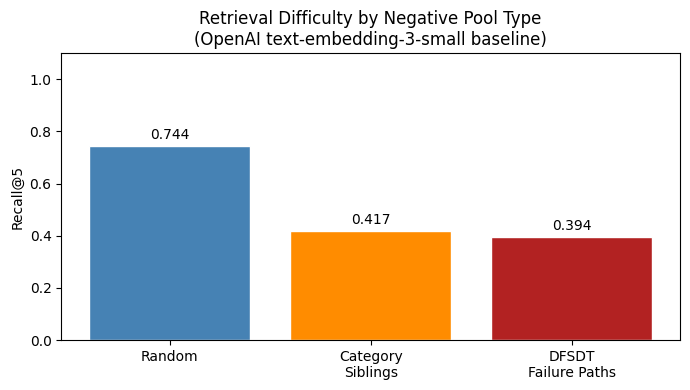

Saved results and figure


In [ ]:
import matplotlib.pyplot as plt

all_results = {
    "random": random_results,
    "sibling": sibling_results,
    "dfsdt": dfsdt_results,
}
with open(PROJECT_DIR / "results_hard_negatives.json", "w") as f:
    json.dump(all_results, f, indent=2)

# Bar chart: Recall@5 across conditions
labels = ["Random", "Category\nSiblings", "DFSDT\nFailure Paths"]
r_at_5 = [random_results["recall@5"], sibling_results["recall@5"], dfsdt_results["recall@5"]]
colors = ["steelblue", "darkorange", "firebrick"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, r_at_5, color=colors, edgecolor="white")
ax.bar_label(bars, fmt="{:.3f}", padding=3)
ax.set_ylabel("Recall@5")
ax.set_title("Retrieval Difficulty by Negative Pool Type\n(OpenAI text-embedding-3-small baseline)")
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.savefig(PROJECT_DIR / "recall_at_5_ablation.png", dpi=150)
plt.show()
print("Saved results and figure")

## DFSDT Pool Purity Analysis

How many queries have enough true DFSDT failure-path negatives to fill the pool without falling back to category siblings?

Queries with 0 DFSDT negatives: 747 / 747 (100.0%)
Queries with >= 99 (full pool):  0 / 747 (0.0%)
Median pure DFSDT negatives:     0
Mean pure DFSDT negatives:       0.0


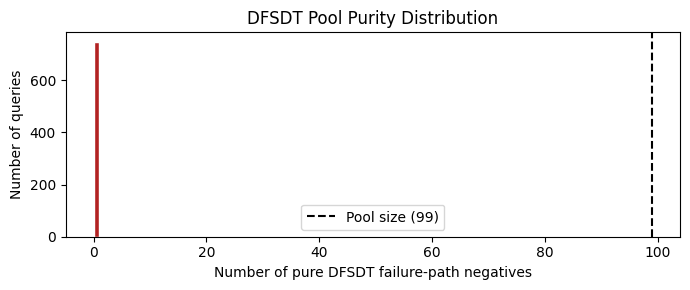

In [ ]:
import re

pure_counts = []
for ex in evals:
    raw_ex = raw_evals[ex["raw_idx"]]
    gt_names = set(ex["ground_truth_apis"])
    seen = set()
    for turn in raw_ex.get("conversations", []):
        if turn["from"] != "assistant":
            continue
        val = turn["value"]
        is_failure = "give_up_and_restart" in val or (
            "Action:" in val and "Finish" not in val and
            any(f in val for f in ["error", "Error", "failed", "Failed"])
        )
        if is_failure and "Action:" in val:
            try:
                api_name = val.split("Action:")[1].split("\n")[0].strip()
                if api_name and api_name not in gt_names and api_name in lookup:
                    seen.add(api_name)
            except IndexError:
                pass
    pure_counts.append(len(seen))

pure_counts = np.array(pure_counts)
print(f"Queries with 0 DFSDT negatives: {(pure_counts == 0).sum()} / {len(pure_counts)} ({(pure_counts == 0).mean():.1%})")
print(f"Queries with >= 99 (full pool):  {(pure_counts >= 99).sum()} / {len(pure_counts)} ({(pure_counts >= 99).mean():.1%})")
print(f"Median pure DFSDT negatives:     {np.median(pure_counts):.0f}")
print(f"Mean pure DFSDT negatives:       {np.mean(pure_counts):.1f}")

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(pure_counts, bins=range(0, max(pure_counts) + 2), color="firebrick", edgecolor="white")
ax.axvline(99, color="black", linestyle="--", label="Pool size (99)")
ax.set_xlabel("Number of pure DFSDT failure-path negatives")
ax.set_ylabel("Number of queries")
ax.set_title("DFSDT Pool Purity Distribution")
ax.legend()
plt.tight_layout()
plt.savefig(PROJECT_DIR / "dfsdt_purity.png", dpi=150)
plt.show()

---

# Notebook 04 — Baseline Analysis and Ablations

## 1. Additional Embedding Models

Compare `text-embedding-3-small` (1536-dim) with `text-embedding-3-large` (3072-dim) to test whether the semantic gap is model-specific or fundamental.

In [ ]:
LARGE_MODEL = 'text-embedding-3-large'

# Embed all APIs with the large model
from tqdm import tqdm

api_strings = [format_api_string(a) for a in corpus]

BATCH = 500
large_embeddings = []
for i in tqdm(range(0, len(api_strings), BATCH), desc='Embedding APIs (large)'):
    embs = get_embeddings(api_strings[i:i+BATCH], model=LARGE_MODEL)
    large_embeddings.append(embs)
large_matrix = np.vstack(large_embeddings)

# Embed queries
queries = [e['user_query'] for e in evals]
large_query_embs = get_embeddings(queries, model=LARGE_MODEL)

print(f'API embeddings: {large_matrix.shape}, Query embeddings: {large_query_embs.shape}')

Embedding APIs (large): 100%|██████████| 10/10 [00:32<00:00,  3.25s/it]


API embeddings: (4518, 3072), Query embeddings: (747, 3072)


In [ ]:
# Full-corpus evaluation with large model
large_index = build_faiss_index(large_matrix)
all_retrieved, all_gt = [], []
for i, ex in enumerate(evals):
    top_k = retrieve_top_k(large_query_embs[i], large_index, k=10)
    all_retrieved.append(top_k)
    all_gt.append([name_to_idx[n] for n in ex['ground_truth_apis'] if n in name_to_idx])

large_results = evaluate_batch(all_retrieved, all_gt, ks=[1, 5, 10])

# Load small model results for comparison
with open(PROJECT_DIR / 'results_baseline.json') as f:
    small_results = json.load(f)['results']

print(f"{'Model':<30} {'R@1':>8} {'R@5':>8} {'R@10':>8} {'MRR':>8}")
print('-' * 62)
for label, r in [('text-embedding-3-small', small_results), ('text-embedding-3-large', large_results)]:
    print(f"{label:<30} {r['recall@1']:>8.4f} {r['recall@5']:>8.4f} {r['recall@10']:>8.4f} {r['mrr']:>8.4f}")

Model                               R@1      R@5     R@10      MRR
--------------------------------------------------------------
text-embedding-3-small           0.9618   0.9726   0.9779   0.0099
text-embedding-3-large           0.9679   0.9766   0.9813   0.0162


In [ ]:
# Hard-negative ablation with large model
with open(TOOLBENCH_DIR / 'toolllama_G123_dfs_eval.json') as f:
    raw_evals = json.load(f)

def eval_restricted_pool(query_embs, corpus_matrix, neg_type, n_neg=99, ks=[1, 5, 10]):
    recall_scores = {k: [] for k in ks}
    mrr_scores = []
    for i, ex in enumerate(evals):
        raw_ex = raw_evals[ex['raw_idx']]
        gt_names = ex['ground_truth_apis']
        gt_indices = [name_to_idx[n] for n in gt_names if n in name_to_idx]
        if not gt_indices:
            continue
        if neg_type == 'random':
            negs = build_random_negatives(corpus, gt_names, n=n_neg)
        elif neg_type == 'sibling':
            negs = build_category_sibling_negatives(corpus, gt_names, lookup, n=n_neg)
        else:
            negs = build_dfsdt_negatives(raw_ex, corpus, gt_names, lookup, n=n_neg)
        cand_names = gt_names + [a['action_name'] for a in negs]
        cand_indices = [name_to_idx[n] for n in cand_names if n in name_to_idx]
        if len(cand_indices) < 2:
            continue
        local_index = build_faiss_index(corpus_matrix[cand_indices].astype(np.float32))
        g2l = {g: j for j, g in enumerate(cand_indices)}
        local_gt = [g2l[g] for g in gt_indices if g in g2l]
        if not local_gt:
            continue
        top_k = retrieve_top_k(query_embs[i], local_index, k=min(10, len(cand_indices)))
        for k in ks:
            recall_scores[k].append(recall_at_k(top_k, local_gt, k))
        mrr_scores.append(mean_reciprocal_rank(top_k, local_gt))
    return {**{f'recall@{k}': float(np.mean(recall_scores[k])) for k in ks}, 'mrr': float(np.mean(mrr_scores))}

large_hn = {}
for neg_type in ['random', 'sibling', 'dfsdt']:
    print(f'Running: {neg_type}...')
    large_hn[neg_type] = eval_restricted_pool(large_query_embs, large_matrix, neg_type)

with open(PROJECT_DIR / 'results_hard_negatives.json') as f:
    small_hn = json.load(f)

print(f"\n{'Model + Condition':<45} {'R@1':>8} {'R@5':>8} {'R@10':>8} {'MRR':>8}")
print('-' * 77)
for model, hn in [('small', small_hn), ('large', large_hn)]:
    for cond in ['random', 'sibling', 'dfsdt']:
        r = hn[cond]
        print(f"text-embedding-3-{model} / {cond:<15} {r['recall@1']:>8.4f} {r['recall@5']:>8.4f} {r['recall@10']:>8.4f} {r['mrr']:>8.4f}")

Running: random...
Running: sibling...
Running: dfsdt...

Model + Condition                                  R@1      R@5     R@10      MRR
-----------------------------------------------------------------------------
text-embedding-3-small / random            0.4167   0.7444   0.9556   0.6954
text-embedding-3-small / sibling           0.1667   0.4167   0.5778   0.3645
text-embedding-3-small / dfsdt             0.1667   0.3944   0.5778   0.3662
text-embedding-3-large / random            0.4833   0.9111   1.0000   0.7809
text-embedding-3-large / sibling           0.2167   0.5444   0.5778   0.4533
text-embedding-3-large / dfsdt             0.2167   0.4778   0.6111   0.4553


## 2. API Format Ablation

Test whether including category, tool name, and parameters in the API string helps retrieval, or if the model only uses the name and description.

In [ ]:
import tiktoken

enc = tiktoken.get_encoding("cl100k_base")  # encoding used by text-embedding-3-*
MAX_TOKENS = 8191

def safe_truncate(text, max_tokens=MAX_TOKENS):
    tokens = enc.encode(text)
    if len(tokens) > max_tokens:
        tokens = tokens[:max_tokens]
        return enc.decode(tokens)
    return text

# Then in the loop:
strings = [safe_truncate(format_api_string(a, mode=mode)) for a in corpus]

In [ ]:
# Embed queries once (shared across all format modes)
queries = [e['user_query'] for e in evals]
query_embs = get_embeddings(queries)

format_results = {}
for mode in ['full', 'name_desc', 'desc_only', 'json']:
    print(f'Format: {mode}...')
    strings = [safe_truncate(format_api_string(a, mode=mode)) for a in corpus]
    embs = []
    for i in tqdm(range(0, len(strings), BATCH), desc=mode):
        embs.append(get_embeddings(strings[i:i+BATCH]))
    matrix = np.vstack(embs)
    index = build_faiss_index(matrix)

    all_retrieved, all_gt = [], []
    for j, ex in enumerate(evals):
        top_k = retrieve_top_k(query_embs[j], index, k=10)
        all_retrieved.append(top_k)
        all_gt.append([name_to_idx[n] for n in ex['ground_truth_apis'] if n in name_to_idx])
    format_results[mode] = evaluate_batch(all_retrieved, all_gt, ks=[1, 5, 10])

print(f"\n{'Format':<15} {'R@1':>8} {'R@5':>8} {'R@10':>8} {'MRR':>8}")
print('-' * 47)
for mode, r in format_results.items():
    print(f"{mode:<15} {r['recall@1']:>8.4f} {r['recall@5']:>8.4f} {r['recall@10']:>8.4f} {r['mrr']:>8.4f}")

Format: full...


full: 100%|██████████| 10/10 [00:06<00:00,  1.53it/s]


Format: name_desc...


name_desc: 100%|██████████| 10/10 [00:00<00:00, 10.17it/s]


Format: desc_only...


desc_only: 100%|██████████| 10/10 [00:20<00:00,  2.05s/it]


Format: json...


json: 100%|██████████| 10/10 [00:23<00:00,  2.37s/it]



Format               R@1      R@5     R@10      MRR
-----------------------------------------------
full              0.9618   0.9726   0.9813   0.0100
name_desc         0.9618   0.9699   0.9710   0.0074
desc_only         0.9636   0.9656   0.9714   0.0081
json              0.9632   0.9705   0.9752   0.0094


## 3. Error Analysis

Analyze where the baseline fails: by category, query complexity, and qualitative examples.

In [ ]:
# Re-run baseline retrieval (or reuse if already in memory)
corpus_matrix = np.load(PROJECT_DIR / 'corpus_embeddings.npy')
query_embs_small = get_embeddings([e['user_query'] for e in evals])
index = build_faiss_index(corpus_matrix)

per_example = []
for i, ex in enumerate(evals):
    top_k = retrieve_top_k(query_embs_small[i], index, k=10)
    gt_indices = [name_to_idx[n] for n in ex['ground_truth_apis'] if n in name_to_idx]
    r1 = recall_at_k(top_k, gt_indices, 1)
    r5 = recall_at_k(top_k, gt_indices, 5)
    mrr = mean_reciprocal_rank(top_k, gt_indices)
    gt_cats = {lookup[n]['category'] for n in ex['ground_truth_apis'] if n in lookup}
    per_example.append({
        'idx': i, 'r1': r1, 'r5': r5, 'mrr': mrr,
        'n_gt': len(gt_indices), 'query_len': len(ex['user_query']),
        'categories': gt_cats, 'top_k': top_k, 'gt_indices': gt_indices,
        'query': ex['user_query'], 'gt_names': ex['ground_truth_apis'],
    })

Category                                      R@5    Count
--------------------------------------------------------
Music                                       0.000       13
Finance                                     0.500        8
...
Music                                       0.000       13
Finance                                     0.500        8


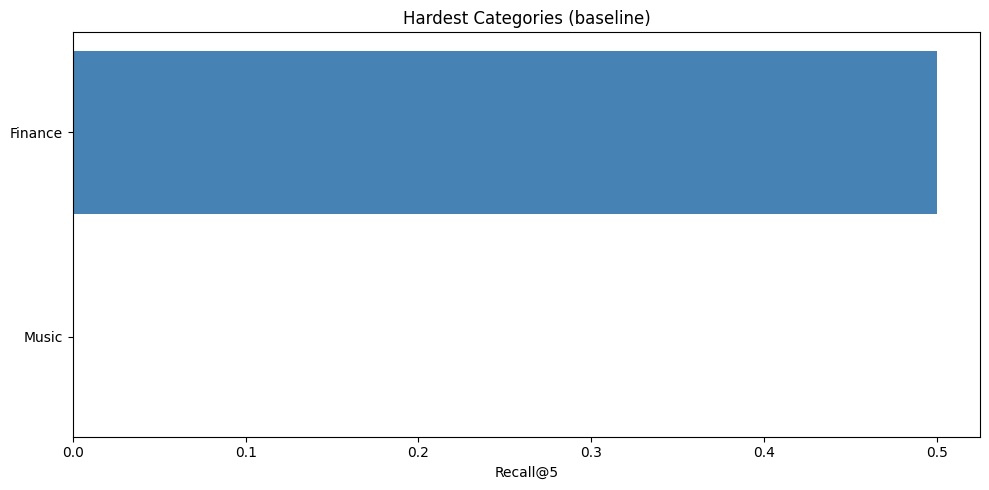

In [ ]:
# 3a. Per-category R@5
from collections import defaultdict

cat_scores = defaultdict(list)
for ex in per_example:
    for cat in ex['categories']:
        cat_scores[cat].append(ex['r5'])

cat_r5 = {cat: np.mean(scores) for cat, scores in cat_scores.items() if len(scores) >= 5}
sorted_cats = sorted(cat_r5.items(), key=lambda x: x[1])

print(f"{'Category':<40} {'R@5':>8} {'Count':>8}")
print('-' * 56)
for cat, score in sorted_cats[:10]:
    print(f"{cat[:40]:<40} {score:>8.3f} {len(cat_scores[cat]):>8}")
print('...')
for cat, score in sorted_cats[-5:]:
    print(f"{cat[:40]:<40} {score:>8.3f} {len(cat_scores[cat]):>8}")

fig, ax = plt.subplots(figsize=(10, 5))
cats_plot = sorted_cats[:15]
ax.barh([c[:30] for c, _ in cats_plot], [s for _, s in cats_plot], color='steelblue')
ax.set_xlabel('Recall@5')
ax.set_title('Hardest Categories (baseline)')
plt.tight_layout()
plt.savefig(PROJECT_DIR / 'error_by_category.png', dpi=150)
plt.show()

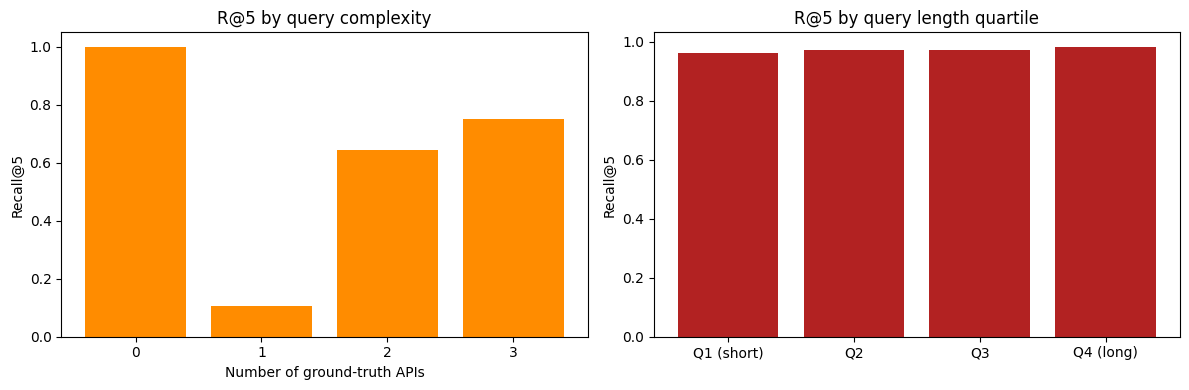

In [ ]:
# 3b. By number of ground-truth APIs and query length
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Group by n_gt
gt_groups = defaultdict(list)
for ex in per_example:
    gt_groups[ex['n_gt']].append(ex['r5'])
gt_sorted = sorted(gt_groups.items())
axes[0].bar([str(k) for k, _ in gt_sorted], [np.mean(v) for _, v in gt_sorted], color='darkorange')
axes[0].set_xlabel('Number of ground-truth APIs')
axes[0].set_ylabel('Recall@5')
axes[0].set_title('R@5 by query complexity')

# Group by query length quartile
lengths = np.array([ex['query_len'] for ex in per_example])
quartiles = np.percentile(lengths, [25, 50, 75])
def qbin(l):
    if l <= quartiles[0]: return 'Q1 (short)'
    if l <= quartiles[1]: return 'Q2'
    if l <= quartiles[2]: return 'Q3'
    return 'Q4 (long)'

len_groups = defaultdict(list)
for ex in per_example:
    len_groups[qbin(ex['query_len'])].append(ex['r5'])
for label in ['Q1 (short)', 'Q2', 'Q3', 'Q4 (long)']:
    axes[1].bar(label, np.mean(len_groups[label]), color='firebrick')
axes[1].set_ylabel('Recall@5')
axes[1].set_title('R@5 by query length quartile')

plt.tight_layout()
plt.savefig(PROJECT_DIR / 'error_by_complexity.png', dpi=150)
plt.show()

In [ ]:
# 3c. Worst failure examples
worst = sorted(per_example, key=lambda x: x['mrr'])[:5]

for rank, ex in enumerate(worst, 1):
    print(f"\n=== Failure #{rank} (MRR={ex['mrr']:.3f}, R@5={ex['r5']:.3f}) ===")
    print(f"Query: {ex['query'][:200]}")
    print(f"Expected: {ex['gt_names'][:3]}")
    retrieved_names = [api_names[j] for j in ex['top_k'][:5]]
    print(f"Retrieved: {retrieved_names}")


=== Failure #1 (MRR=0.000, R@5=1.000) ===
Query: 
I'm a sports enthusiast and I'm interested in attending a greyhound race. Can you give me the race schedule for this week? I would like to know the dates, timings, and locations of the races. Additio
Expected: ['racecards_for_greyhound_racing_uk', 'race_detail_info_for_greyhound_racing_uk', 'results_for_greyhound_racing_uk']
Retrieved: ['racing_details_for_flashlive_sports', 'schedule_live_for_os_sports_perform', 'races_motorsport_for_os_sports_perform', 'schedule_odds_for_os_sports_perform', 'schedule_by_date_for_os_sports_perform']

=== Failure #2 (MRR=0.000, R@5=1.000) ===
Query: 
I am a music enthusiast and I need help finding the latest coupons for purchasing musical instruments. Can you provide me with the latest coupons and popular coupons? Additionally, I would like to ex
Expected: ['latest_coupons_for_get_27coupons', 'trending_coupons_for_get_27coupons', 'sortproductsmaster_for_tokopedia_super_api']
Retrieved: ['coupon_info_fo

In [ ]:
# Save all Phase 1 results
phase1_results = {
    'model_comparison': {
        'text-embedding-3-small': small_results,
        'text-embedding-3-large': large_results,
    },
    'format_ablation': format_results,
    'per_category_r5': {cat: float(score) for cat, score in sorted_cats},
}
with open(PROJECT_DIR / 'results_phase1.json', 'w') as f:
    json.dump(phase1_results, f, indent=2)
print('Saved results_phase1.json')

Saved results_phase1.json


---

# Notebook 05 — Contrastive Fine-Tuning

In [ ]:
corpus = load_api_corpus(TOOLBENCH_DIR / 'toolenv' / 'tools')
lookup = build_api_lookup(corpus)

TRAIN_PATH = TOOLBENCH_DIR / 'toolllama_G123_dfs_train.json'
assert TRAIN_PATH.exists(), f'Training file not found: {TRAIN_PATH}'

train_examples = load_eval_examples(TRAIN_PATH)
with open(TRAIN_PATH) as f:
    raw_train = json.load(f)

print(f'Corpus: {len(corpus)} APIs | Training: {len(train_examples)} examples')

Corpus: 4518 APIs | Training: 184870 examples


## Configuration

In [ ]:
BASE_MODEL = 'sentence-transformers/all-MiniLM-L6-v2'
EPOCHS = 5
BATCH_SIZE = 64
N_HARD_NEGATIVES = 7

## Variant 2: In-Batch Negatives Only

Each training pair is (query, positive API). The loss treats all other positives in the batch as implicit negatives.

In [ ]:
from sentence_transformers import SentenceTransformer, InputExample, losses
from torch.utils.data import DataLoader

pairs_v2 = []
for ex in train_examples:
    for name in ex['ground_truth_apis']:
        if name in lookup:
            pairs_v2.append(InputExample(texts=[
                ex['user_query'],
                format_api_string(lookup[name]),
            ]))
random.shuffle(pairs_v2)
print(f'Variant 2: {len(pairs_v2)} training pairs')

model_v2 = SentenceTransformer(BASE_MODEL)
loader_v2 = DataLoader(pairs_v2, shuffle=True, batch_size=BATCH_SIZE)
loss_v2 = losses.MultipleNegativesRankingLoss(model_v2)

model_v2.fit(
    train_objectives=[(loader_v2, loss_v2)],
    epochs=EPOCHS,
    warmup_steps=int(0.1 * len(loader_v2) * EPOCHS),
    output_path=str(PROJECT_DIR / 'checkpoints' / 'v2_random'),
    show_progress_bar=True,
)
print('Variant 2 saved to checkpoints/v2_random')

/tmp/ipykernel_632/3081138080.py:1: DeprecationWarning: Importing from 'sentence_transformers.losses' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.losses' instead.
  from sentence_transformers import SentenceTransformer, InputExample, losses


Variant 2: 21783 training pairs


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss
500,1.090964
1000,0.779300
1500,0.697135


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Variant 2 saved to checkpoints/v2_random


## Variant 3: Explicit Hard Negatives

Each training tuple is (query, positive, neg1, ..., neg7). Negatives come from DFSDT failure paths, padded with category siblings when needed. The loss uses these as explicit negatives on top of in-batch negatives.

In [ ]:
pairs_v3 = []
for ex in train_examples:
    raw_ex = raw_train[ex['raw_idx']]
    for name in ex['ground_truth_apis']:
        if name not in lookup:
            continue
        hard_negs = build_dfsdt_negatives(raw_ex, corpus, ex['ground_truth_apis'], lookup, n=N_HARD_NEGATIVES)
        neg_texts = [format_api_string(n) for n in hard_negs]
        if len(neg_texts) < N_HARD_NEGATIVES:
            continue
        pairs_v3.append(InputExample(texts=[
            ex['user_query'],
            format_api_string(lookup[name]),
        ] + neg_texts))
random.shuffle(pairs_v3)
print(f'Variant 3: {len(pairs_v3)} training pairs')

model_v3 = SentenceTransformer(BASE_MODEL)
loader_v3 = DataLoader(pairs_v3, shuffle=True, batch_size=BATCH_SIZE)
loss_v3 = losses.MultipleNegativesRankingLoss(model_v3)

model_v3.fit(
    train_objectives=[(loader_v3, loss_v3)],
    epochs=EPOCHS,
    warmup_steps=int(0.1 * len(loader_v3) * EPOCHS),
    output_path=str(PROJECT_DIR / 'checkpoints' / 'v3_hard'),
    show_progress_bar=True,
)
print('Variant 3 saved to checkpoints/v3_hard')

Variant 3: 20903 training pairs


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss
500,2.024219
1000,1.434061
1500,1.291212


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Variant 3 saved to checkpoints/v3_hard


---

# Notebook 06 — Fine-Tuned Model Evaluation

In [ ]:
corpus = load_api_corpus(TOOLBENCH_DIR / 'toolenv' / 'tools')
lookup = build_api_lookup(corpus)
evals = load_eval_examples(TOOLBENCH_DIR / 'toolllama_G123_dfs_eval.json')

with open(PROJECT_DIR / 'api_names.json') as f:
    api_names = json.load(f)
name_to_idx = {name: i for i, name in enumerate(api_names)}

api_strings = [format_api_string(a) for a in corpus]
queries = [e['user_query'] for e in evals]

print(f'Corpus: {len(corpus)} APIs | Eval: {len(evals)} examples')

Corpus: 4518 APIs | Eval: 747 examples


## Encode Corpus with Fine-Tuned Models

In [ ]:
from sentence_transformers import SentenceTransformer

models = {}
embeddings = {}
code_strings = [format_api_code(a) for a in corpus]

for label, path in [('v2_random', 'checkpoints/v2_random'), ('v3_hard', 'checkpoints/v3_hard'), ('v4_hierarchical', 'checkpoints/v4_hierarchical'), ('v5_trimodal', 'checkpoints/v5_trimodal')]:
    model_path = PROJECT_DIR / path
    if not model_path.exists():
        print(f'Skipping {label}: checkpoint not found at {model_path}')
        continue
    print(f'Encoding with {label}...')
    model = SentenceTransformer(str(model_path))
    models[label] = model
    corpus_embs = model.encode(api_strings, show_progress_bar=True, batch_size=256)
    if 'trimodal' in label:
        code_embs = model.encode(code_strings, show_progress_bar=True, batch_size=256)
        corpus_embs = (corpus_embs + code_embs) / 2
    embeddings[label] = {
        'corpus': corpus_embs,
        'queries': model.encode(queries, batch_size=256),
    }

print(f'Loaded {len(models)} fine-tuned models')

Encoding with v2_random...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/18 [00:00<?, ?it/s]

Encoding with v3_hard...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/18 [00:00<?, ?it/s]

Skipping v4_hierarchical: checkpoint not found at /content/repo/project/checkpoints/v4_hierarchical
Skipping v5_trimodal: checkpoint not found at /content/repo/project/checkpoints/v5_trimodal
Loaded 2 fine-tuned models


## Full-Corpus Evaluation

In [ ]:
with open(PROJECT_DIR / 'results_baseline.json') as f:
    baseline = json.load(f)['results']

full_corpus_results = {'baseline (text-embedding-3-small)': baseline}

for label, embs in embeddings.items():
    index = build_faiss_index(embs['corpus'])
    all_retrieved, all_gt = [], []
    for i, ex in enumerate(evals):
        top_k = retrieve_top_k(embs['queries'][i], index, k=10)
        all_retrieved.append(top_k)
        all_gt.append([name_to_idx[n] for n in ex['ground_truth_apis'] if n in name_to_idx])
    full_corpus_results[label] = evaluate_batch(all_retrieved, all_gt, ks=[1, 5, 10])

print(f"{'Model':<40} {'R@1':>8} {'R@5':>8} {'R@10':>8} {'MRR':>8}")
print('-' * 72)
for label, r in full_corpus_results.items():
    print(f"{label:<40} {r['recall@1']:>8.4f} {r['recall@5']:>8.4f} {r['recall@10']:>8.4f} {r['mrr']:>8.4f}")

Model                                         R@1      R@5     R@10      MRR
------------------------------------------------------------------------
baseline (text-embedding-3-small)          0.9618   0.9726   0.9779   0.0099
v2_random                                  0.9730   0.9851   0.9902   0.0219
v3_hard                                    0.9723   0.9862   0.9933   0.0231


## Hard-Negative Ablation

Same restricted 100-candidate pool evaluation as notebook 03, now comparing baseline vs fine-tuned models.

In [ ]:
with open(TOOLBENCH_DIR / 'toolllama_G123_dfs_eval.json') as f:
    raw_evals = json.load(f)

def eval_restricted_pool(query_embs, corpus_embs, neg_type, n_neg=99, ks=[1, 5, 10]):
    recall_scores = {k: [] for k in ks}
    mrr_scores = []
    for i, ex in enumerate(evals):
        raw_ex = raw_evals[ex['raw_idx']]
        gt_names = ex['ground_truth_apis']
        gt_indices = [name_to_idx[n] for n in gt_names if n in name_to_idx]
        if not gt_indices:
            continue
        if neg_type == 'random':
            negs = build_random_negatives(corpus, gt_names, n=n_neg)
        elif neg_type == 'sibling':
            negs = build_category_sibling_negatives(corpus, gt_names, lookup, n=n_neg)
        else:
            negs = build_dfsdt_negatives(raw_ex, corpus, gt_names, lookup, n=n_neg)
        cand_indices = [name_to_idx[n] for n in gt_names + [a['action_name'] for a in negs] if n in name_to_idx]
        if len(cand_indices) < 2:
            continue
        local_index = build_faiss_index(corpus_embs[cand_indices].astype(np.float32))
        g2l = {g: j for j, g in enumerate(cand_indices)}
        local_gt = [g2l[g] for g in gt_indices if g in g2l]
        if not local_gt:
            continue
        top_k = retrieve_top_k(query_embs[i], local_index, k=min(10, len(cand_indices)))
        for k in ks:
            recall_scores[k].append(recall_at_k(top_k, local_gt, k))
        mrr_scores.append(mean_reciprocal_rank(top_k, local_gt))
    return {**{f'recall@{k}': float(np.mean(recall_scores[k])) for k in ks}, 'mrr': float(np.mean(mrr_scores))}

In [ ]:
with open(PROJECT_DIR / 'results_hard_negatives.json') as f:
    baseline_hn = json.load(f)

hn_results = {'baseline': baseline_hn}
for label, embs in embeddings.items():
    hn_results[label] = {}
    for neg_type in ['random', 'sibling', 'dfsdt']:
        print(f'{label} / {neg_type}...')
        hn_results[label][neg_type] = eval_restricted_pool(embs['queries'], embs['corpus'], neg_type)

print(f"\n{'Model / Condition':<45} {'R@1':>8} {'R@5':>8} {'R@10':>8} {'MRR':>8}")
print('-' * 77)
for model_label, conditions in hn_results.items():
    for cond, r in conditions.items():
        print(f"{model_label} / {cond:<20} {r['recall@1']:>8.4f} {r['recall@5']:>8.4f} {r['recall@10']:>8.4f} {r['mrr']:>8.4f}")

v2_random / random...
v2_random / sibling...
v2_random / dfsdt...
v3_hard / random...
v3_hard / sibling...
v3_hard / dfsdt...

Model / Condition                                  R@1      R@5     R@10      MRR
-----------------------------------------------------------------------------
baseline / random                 0.4167   0.7444   0.9556   0.6954
baseline / sibling                0.1667   0.4167   0.5778   0.3645
baseline / dfsdt                  0.1667   0.3944   0.5778   0.3662
v2_random / random                 0.6944   1.0000   1.0000   0.9500
v2_random / sibling                0.3778   0.6556   0.8667   0.6002
v2_random / dfsdt                  0.3778   0.6889   0.8333   0.5999
v3_hard / random                 0.7944   1.0000   1.0000   1.0000
v3_hard / sibling                0.3278   0.8667   1.0000   0.6457
v3_hard / dfsdt                  0.3611   0.8000   1.0000   0.6657


## Save Results

In [ ]:
results = {
    'full_corpus': {k: v for k, v in full_corpus_results.items()},
    'hard_negative_ablation': hn_results,
}
with open(PROJECT_DIR / 'results_finetuned.json', 'w') as f:
    json.dump(results, f, indent=2)
print('Saved results_finetuned.json')

Saved results_finetuned.json


---

# Notebook 07 — Hierarchical Contrastive Training

In [ ]:
corpus = load_api_corpus(TOOLBENCH_DIR / 'toolenv' / 'tools')
lookup = build_api_lookup(corpus)

TRAIN_PATH = TOOLBENCH_DIR / 'toolllama_G123_dfs_train.json'
assert TRAIN_PATH.exists(), f'Training file not found: {TRAIN_PATH}'

train_examples = load_eval_examples(TRAIN_PATH)
with open(TRAIN_PATH) as f:
    raw_train = json.load(f)

print(f'Corpus: {len(corpus)} APIs | Training: {len(train_examples)} examples')
print(f'Categories: {len(set(a["category"] for a in corpus))}')

Corpus: 4518 APIs | Training: 184870 examples
Categories: 32


## Hierarchical Loss

Combines API-level and category-level contrastive objectives. The category term uses in-batch negatives over category name embeddings.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class HierarchicalLoss(nn.Module):
    def __init__(self, model, scale=20.0, lambda_cat=0.1):
        super().__init__()
        self.model = model
        self.scale = scale
        self.lambda_cat = lambda_cat

    def forward(self, sentence_features, labels):
        reps = [self.model(sf)['sentence_embedding'] for sf in sentence_features]
        queries = reps[0]      # (B, D)
        categories = reps[2]   # (B, D)

        # API-level loss: query vs [positive_api, hard_neg1, ..., hard_negK]
        api_pool = torch.cat(reps[1:2] + reps[3:], dim=0)
        sim_api = F.cosine_similarity(queries.unsqueeze(1), api_pool.unsqueeze(0), dim=-1) * self.scale
        target = torch.arange(queries.size(0), device=queries.device)
        loss_api = F.cross_entropy(sim_api, target)

        # Category-level loss: query vs category names (in-batch negatives)
        sim_cat = F.cosine_similarity(queries.unsqueeze(1), categories.unsqueeze(0), dim=-1) * self.scale
        loss_cat = F.cross_entropy(sim_cat, target)

        return loss_api + self.lambda_cat * loss_cat

## Build Training Data

Each example: [query, positive_api, category_name, hard_neg1, ..., hard_neg7]

In [ ]:
from sentence_transformers import SentenceTransformer, InputExample
from torch.utils.data import DataLoader

BASE_MODEL = 'sentence-transformers/all-MiniLM-L6-v2'
EPOCHS = 5
BATCH_SIZE = 64
N_HARD_NEGATIVES = 7
LAMBDA_CAT = 0.1

pairs = []
for ex in train_examples:
    raw_ex = raw_train[ex['raw_idx']]
    for name in ex['ground_truth_apis']:
        if name not in lookup:
            continue
        api = lookup[name]
        hard_negs = build_dfsdt_negatives(raw_ex, corpus, ex['ground_truth_apis'], lookup, n=N_HARD_NEGATIVES)
        neg_texts = [format_api_string(n) for n in hard_negs]
        if len(neg_texts) < N_HARD_NEGATIVES:
            continue
        pairs.append(InputExample(texts=[
            ex['user_query'],
            format_api_string(api),
            api['category'],
        ] + neg_texts))

random.shuffle(pairs)
print(f'Variant 4: {len(pairs)} training pairs')

Variant 4: 20903 training pairs


## Train

In [ ]:
model = SentenceTransformer(BASE_MODEL)
loader = DataLoader(pairs, shuffle=True, batch_size=BATCH_SIZE)
loss = HierarchicalLoss(model, lambda_cat=LAMBDA_CAT)

model.fit(
    train_objectives=[(loader, loss)],
    epochs=EPOCHS,
    warmup_steps=int(0.1 * len(loader) * EPOCHS),
    output_path=str(PROJECT_DIR / 'checkpoints' / 'v4_hierarchical'),
    show_progress_bar=True,
)
print('Variant 4 saved to checkpoints/v4_hierarchical')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss
500,2.290152
1000,1.669881
1500,1.515395


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Variant 4 saved to checkpoints/v4_hierarchical


---

# Notebook 08 — Tri-Modal Training

In [ ]:
corpus = load_api_corpus(TOOLBENCH_DIR / 'toolenv' / 'tools')
lookup = build_api_lookup(corpus)

TRAIN_PATH = TOOLBENCH_DIR / 'toolllama_G123_dfs_train.json'
assert TRAIN_PATH.exists(), f'Training file not found: {TRAIN_PATH}'

train_examples = load_eval_examples(TRAIN_PATH)
with open(TRAIN_PATH) as f:
    raw_train = json.load(f)

# Preview the code format
sample = corpus[0]
print(f'Doc:  {format_api_string(sample)}')
print(f'Code: {format_api_code(sample)}')
print(f'\nCorpus: {len(corpus)} APIs | Training: {len(train_examples)} examples')

Doc:  Artificial_Intelligence_Machine_Learning > Object Detection: Detect - Detect objects present in the photo, if there is 10 of thing X, the X thing will repeat 10 times in the result, each X has their bounding box(4 coordinations), the photo param is your jpg photo base64 encoded, the minscore is the minimum score you would like to get, it is between 0 & 1, the maximum number of detections is 100 | Parameters: photo, minscore
Code: def detect(photo: STRING, minscore: STRING) -> dict: ...

Corpus: 4518 APIs | Training: 184870 examples


## Tri-Modal Loss

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class TriModalLoss(nn.Module):
    def __init__(self, model, scale=20.0, lambda_code=0.5):
        super().__init__()
        self.model = model
        self.scale = scale
        self.lambda_code = lambda_code

    def forward(self, sentence_features, labels):
        # [0]=query, [1]=doc, [2]=code, [3:]=hard negatives (doc format)
        reps = [self.model(sf)['sentence_embedding'] for sf in sentence_features]
        queries = reps[0]
        docs = reps[1]
        codes = reps[2]
        target = torch.arange(queries.size(0), device=queries.device)

        # Query <> Doc (with hard negatives)
        doc_pool = torch.cat(reps[1:2] + reps[3:], dim=0)
        sim_qd = F.cosine_similarity(queries.unsqueeze(1), doc_pool.unsqueeze(0), dim=-1) * self.scale
        loss_qd = F.cross_entropy(sim_qd, target)

        # Query <> Code (in-batch negatives)
        sim_qc = F.cosine_similarity(queries.unsqueeze(1), codes.unsqueeze(0), dim=-1) * self.scale
        loss_qc = F.cross_entropy(sim_qc, target)

        # Doc <> Code (in-batch negatives)
        sim_dc = F.cosine_similarity(docs.unsqueeze(1), codes.unsqueeze(0), dim=-1) * self.scale
        loss_dc = F.cross_entropy(sim_dc, target)

        return loss_qd + self.lambda_code * (loss_qc + loss_dc)

## Build Training Data

Each example: [query, api_doc, api_code, hard_neg1, ..., hard_neg7]

In [ ]:
from sentence_transformers import SentenceTransformer, InputExample
from torch.utils.data import DataLoader

BASE_MODEL = 'sentence-transformers/all-MiniLM-L6-v2'
EPOCHS = 5
BATCH_SIZE = 64
N_HARD_NEGATIVES = 7
LAMBDA_CODE = 0.5

pairs = []
for ex in train_examples:
    raw_ex = raw_train[ex['raw_idx']]
    for name in ex['ground_truth_apis']:
        if name not in lookup:
            continue
        api = lookup[name]
        hard_negs = build_dfsdt_negatives(raw_ex, corpus, ex['ground_truth_apis'], lookup, n=N_HARD_NEGATIVES)
        neg_texts = [format_api_string(n) for n in hard_negs]
        if len(neg_texts) < N_HARD_NEGATIVES:
            continue
        pairs.append(InputExample(texts=[
            ex['user_query'],
            format_api_string(api),
            format_api_code(api),
        ] + neg_texts))

random.shuffle(pairs)
print(f'Variant 5: {len(pairs)} training pairs')

Variant 5: 20903 training pairs


## Train

In [ ]:
model = SentenceTransformer(BASE_MODEL)
loader = DataLoader(pairs, shuffle=True, batch_size=BATCH_SIZE)
loss = TriModalLoss(model, lambda_code=LAMBDA_CODE)

model.fit(
    train_objectives=[(loader, loss)],
    epochs=EPOCHS,
    warmup_steps=int(0.1 * len(loader) * EPOCHS),
    output_path=str(PROJECT_DIR / 'checkpoints' / 'v5_trimodal'),
    show_progress_bar=True,
)
print('Variant 5 saved to checkpoints/v5_trimodal')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss
500,3.037484
1000,2.067827
1500,1.851005


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Variant 5 saved to checkpoints/v5_trimodal


---

# Notebook 09 — Final Evaluation and Analysis

In [ ]:
corpus = load_api_corpus(TOOLBENCH_DIR / 'toolenv' / 'tools')
lookup = build_api_lookup(corpus)
evals = load_eval_examples(TOOLBENCH_DIR / 'toolllama_G123_dfs_eval.json')

with open(PROJECT_DIR / 'api_names.json') as f:
    api_names = json.load(f)
name_to_idx = {name: i for i, name in enumerate(api_names)}

with open(TOOLBENCH_DIR / 'toolllama_G123_dfs_eval.json') as f:
    raw_evals = json.load(f)

api_strings = [format_api_string(a) for a in corpus]
code_strings = [format_api_code(a) for a in corpus]
queries = [e['user_query'] for e in evals]

print(f'Corpus: {len(corpus)} APIs | Eval: {len(evals)} examples')

Corpus: 4518 APIs | Eval: 747 examples


## Encode All Models

Load fine-tuned checkpoints and compute corpus/query embeddings for each variant.

In [ ]:
from sentence_transformers import SentenceTransformer

model_configs = [
    ('v2_random', 'checkpoints/v2_random', False),
    ('v3_hard', 'checkpoints/v3_hard', False),
    ('v4_hierarchical', 'checkpoints/v4_hierarchical', False),
    ('v5_trimodal', 'checkpoints/v5_trimodal', True),
]

embeddings = {}
for label, path, trimodal in model_configs:
    model_path = PROJECT_DIR / path
    if not model_path.exists():
        print(f'Skipping {label}: checkpoint not found')
        continue
    print(f'Encoding with {label}...')
    model = SentenceTransformer(str(model_path))
    corpus_embs = model.encode(api_strings, show_progress_bar=True, batch_size=256)
    if trimodal:
        code_embs = model.encode(code_strings, show_progress_bar=True, batch_size=256)
        corpus_embs = (corpus_embs + code_embs) / 2
    embeddings[label] = {
        'corpus': corpus_embs,
        'queries': model.encode(queries, batch_size=256),
    }

print(f'Loaded {len(embeddings)} fine-tuned models')

Encoding with v2_random...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/18 [00:00<?, ?it/s]

Encoding with v3_hard...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

Encoding with v5_trimodal...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/18 [00:00<?, ?it/s]

Batches:   0%|          | 0/18 [00:00<?, ?it/s]

Loaded 4 fine-tuned models


## 1. Comprehensive Comparison Table

Full-corpus retrieval and restricted 100-candidate pool evaluation across all models and negative conditions.

In [ ]:
def per_example_scores(query_embs, corpus_embs, ks=[1, 5, 10]):
    """Return per-example recall and MRR scores for bootstrap analysis."""
    index = build_faiss_index(corpus_embs)
    scores = []
    for i, ex in enumerate(evals):
        top_k = retrieve_top_k(query_embs[i], index, k=max(ks))
        gt = [name_to_idx[n] for n in ex['ground_truth_apis'] if n in name_to_idx]
        row = {}
        for k in ks:
            row[f'r@{k}'] = recall_at_k(top_k, gt, k)
        row['mrr'] = mean_reciprocal_rank(top_k, gt)
        row['top_k'] = top_k
        row['gt'] = gt
        scores.append(row)
    return scores

def per_example_restricted(query_embs, corpus_embs, neg_type, n_neg=99, ks=[1, 5, 10]):
    """Return per-example scores for restricted pool evaluation."""
    scores = []
    for i, ex in enumerate(evals):
        raw_ex = raw_evals[ex['raw_idx']]
        gt_names = ex['ground_truth_apis']
        gt_indices = [name_to_idx[n] for n in gt_names if n in name_to_idx]
        if not gt_indices:
            continue
        if neg_type == 'random':
            negs = build_random_negatives(corpus, gt_names, n=n_neg)
        elif neg_type == 'sibling':
            negs = build_category_sibling_negatives(corpus, gt_names, lookup, n=n_neg)
        else:
            negs = build_dfsdt_negatives(raw_ex, corpus, gt_names, lookup, n=n_neg)
        cand_indices = [name_to_idx[n] for n in gt_names + [a['action_name'] for a in negs] if n in name_to_idx]
        if len(cand_indices) < 2:
            continue
        local_index = build_faiss_index(corpus_embs[cand_indices].astype(np.float32))
        g2l = {g: j for j, g in enumerate(cand_indices)}
        local_gt = [g2l[g] for g in gt_indices if g in g2l]
        if not local_gt:
            continue
        top_k = retrieve_top_k(query_embs[i], local_index, k=min(max(ks), len(cand_indices)))
        row = {'example_idx': i}
        for k in ks:
            row[f'r@{k}'] = recall_at_k(top_k, local_gt, k)
        row['mrr'] = mean_reciprocal_rank(top_k, local_gt)
        scores.append(row)
    return scores

print('Scoring functions defined.')

Scoring functions defined.


In [ ]:
# Load baseline embeddings for per-example scoring
from models.embeddings import get_embeddings

baseline_corpus = np.load(PROJECT_DIR / 'corpus_embeddings.npy')
baseline_queries = get_embeddings(queries)

# Full-corpus per-example scores for all models
all_full_scores = {}
all_full_scores['baseline'] = per_example_scores(baseline_queries, baseline_corpus)

for label, embs in embeddings.items():
    print(f'Full-corpus: {label}...')
    all_full_scores[label] = per_example_scores(embs['queries'], embs['corpus'])

# Aggregate results table
full_results = {}
for label, scores in all_full_scores.items():
    full_results[label] = {
        f'recall@{k}': np.mean([s[f'r@{k}'] for s in scores])
        for k in [1, 5, 10]
    }
    full_results[label]['mrr'] = np.mean([s['mrr'] for s in scores])

print(f"\n{'Model':<30} {'R@1':>8} {'R@5':>8} {'R@10':>8} {'MRR':>8}")
print('-' * 62)
for label, r in full_results.items():
    print(f"{label:<30} {r['recall@1']:>8.4f} {r['recall@5']:>8.4f} {r['recall@10']:>8.4f} {r['mrr']:>8.4f}")

Full-corpus: v2_random...
Full-corpus: v3_hard...
Full-corpus: v4_hierarchical...
Full-corpus: v5_trimodal...

Model                               R@1      R@5     R@10      MRR
--------------------------------------------------------------
baseline                         0.9618   0.9726   0.9779   0.0100
v2_random                        0.9730   0.9851   0.9902   0.0219
v3_hard                          0.9723   0.9862   0.9933   0.0231
v4_hierarchical                  0.9723   0.9848   0.9973   0.0236
v5_trimodal                      0.9705   0.9824   0.9862   0.0202


In [ ]:
# Hard-negative ablation per-example scores
all_hn_scores = {}

# Baseline
all_hn_scores['baseline'] = {}
for neg_type in ['random', 'sibling', 'dfsdt']:
    print(f'baseline / {neg_type}...')
    all_hn_scores['baseline'][neg_type] = per_example_restricted(baseline_queries, baseline_corpus, neg_type)

# Fine-tuned models
for label, embs in embeddings.items():
    all_hn_scores[label] = {}
    for neg_type in ['random', 'sibling', 'dfsdt']:
        print(f'{label} / {neg_type}...')
        all_hn_scores[label][neg_type] = per_example_restricted(embs['queries'], embs['corpus'], neg_type)

# Aggregate
hn_results = {}
for model_label, conditions in all_hn_scores.items():
    hn_results[model_label] = {}
    for cond, scores in conditions.items():
        hn_results[model_label][cond] = {
            f'recall@{k}': np.mean([s[f'r@{k}'] for s in scores])
            for k in [1, 5, 10]
        }
        hn_results[model_label][cond]['mrr'] = np.mean([s['mrr'] for s in scores])

print(f"\n{'Model / Condition':<45} {'R@1':>8} {'R@5':>8} {'R@10':>8} {'MRR':>8}")
print('-' * 77)
for model_label, conditions in hn_results.items():
    for cond, r in conditions.items():
        tag = f'{model_label} / {cond}'
        print(f"{tag:<45} {r['recall@1']:>8.4f} {r['recall@5']:>8.4f} {r['recall@10']:>8.4f} {r['mrr']:>8.4f}")

baseline / random...
baseline / sibling...
baseline / dfsdt...
v2_random / random...
v2_random / sibling...
v2_random / dfsdt...
v3_hard / random...
v3_hard / sibling...
v3_hard / dfsdt...
v4_hierarchical / random...
v4_hierarchical / sibling...
v4_hierarchical / dfsdt...
v5_trimodal / random...
v5_trimodal / sibling...
v5_trimodal / dfsdt...

Model / Condition                                  R@1      R@5     R@10      MRR
-----------------------------------------------------------------------------
baseline / random                               0.3500   0.8444   0.9889   0.6665
baseline / sibling                              0.1333   0.4611   0.5778   0.3556
baseline / dfsdt                                0.1333   0.3944   0.5778   0.3534
v2_random / random                              0.6778   1.0000   1.0000   0.9194
v2_random / sibling                             0.3611   0.7222   0.8333   0.5857
v2_random / dfsdt                               0.3778   0.6889   0.8333   0.6043
v3

## 2. Statistical Significance

Bootstrap confidence intervals (95%) on the difference between each fine-tuned model and the baseline. A difference is significant if the CI excludes zero.

In [ ]:
def bootstrap_ci(scores_a, scores_b, metric, n_boot=10000, alpha=0.05):
    """Bootstrap 95% CI for mean(scores_b[metric]) - mean(scores_a[metric])."""
    a = np.array([s[metric] for s in scores_a])
    b = np.array([s[metric] for s in scores_b])
    n = min(len(a), len(b))
    a, b = a[:n], b[:n]
    diffs = []
    rng = np.random.default_rng(42)
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        diffs.append(b[idx].mean() - a[idx].mean())
    diffs = np.sort(diffs)
    lo = diffs[int(alpha / 2 * n_boot)]
    hi = diffs[int((1 - alpha / 2) * n_boot)]
    mean_diff = np.mean(diffs)
    sig = 'Yes' if (lo > 0 or hi < 0) else 'No'
    return mean_diff, lo, hi, sig

# Full-corpus significance tests
baseline_scores = all_full_scores['baseline']

print(f"{'Model vs baseline':<25} {'Metric':<8} {'Diff':>8} {'95% CI':>20} {'Sig?':>6}")
print('-' * 70)
for label in embeddings:
    model_scores = all_full_scores[label]
    for metric in ['r@5', 'mrr']:
        diff, lo, hi, sig = bootstrap_ci(baseline_scores, model_scores, metric)
        print(f"{label:<25} {metric:<8} {diff:>+8.4f} [{lo:>+8.4f}, {hi:>+8.4f}] {sig:>6}")

Model vs baseline         Metric       Diff               95% CI   Sig?
----------------------------------------------------------------------
v2_random                 r@5       +0.0124 [ +0.0054,  +0.0205]    Yes
v2_random                 mrr       +0.0118 [ +0.0055,  +0.0194]    Yes
v3_hard                   r@5       +0.0136 [ +0.0062,  +0.0221]    Yes
v3_hard                   mrr       +0.0130 [ +0.0065,  +0.0205]    Yes
v4_hierarchical           r@5       +0.0122 [ +0.0056,  +0.0201]    Yes
v4_hierarchical           mrr       +0.0135 [ +0.0071,  +0.0210]    Yes
v5_trimodal               r@5       +0.0098 [ +0.0033,  +0.0170]    Yes
v5_trimodal               mrr       +0.0101 [ +0.0045,  +0.0168]    Yes


In [ ]:
# Hard-negative significance: compare each model on DFSDT condition vs baseline
print(f"{'Model vs baseline (DFSDT)':<25} {'Metric':<8} {'Diff':>8} {'95% CI':>20} {'Sig?':>6}")
print('-' * 70)
baseline_dfsdt = all_hn_scores['baseline']['dfsdt']
for label in embeddings:
    model_dfsdt = all_hn_scores[label]['dfsdt']
    for metric in ['r@1', 'r@5', 'mrr']:
        diff, lo, hi, sig = bootstrap_ci(baseline_dfsdt, model_dfsdt, metric)
        print(f"{label:<25} {metric:<8} {diff:>+8.4f} [{lo:>+8.4f}, {hi:>+8.4f}] {sig:>6}")

Model vs baseline (DFSDT) Metric       Diff               95% CI   Sig?
----------------------------------------------------------------------
v2_random                 r@1       +0.2456 [ +0.1000,  +0.4111]    Yes
v2_random                 r@5       +0.2949 [ +0.1500,  +0.4500]    Yes
v2_random                 mrr       +0.2521 [ +0.1276,  +0.3918]    Yes
v3_hard                   r@1       +0.1789 [ +0.0500,  +0.3167]    Yes
v3_hard                   r@5       +0.4065 [ +0.2500,  +0.5722]    Yes
v3_hard                   mrr       +0.2745 [ +0.1527,  +0.4036]    Yes
v4_hierarchical           r@1       +0.1789 [ +0.0500,  +0.3167]    Yes
v4_hierarchical           r@5       +0.5063 [ +0.3389,  +0.6667]    Yes
v4_hierarchical           mrr       +0.2772 [ +0.1569,  +0.4046]    Yes
v5_trimodal               r@1       +0.1616 [ +0.0556,  +0.2833]    Yes
v5_trimodal               r@5       +0.2957 [ +0.1167,  +0.4667]    Yes
v5_trimodal               mrr       +0.2486 [ +0.1355,  +0.3694] 

## 3. Ablation: Negative Mining Strategy

Compare how each model handles different negative difficulties. The gap between random and DFSDT performance reveals robustness to hard negatives.

Model                       R@5 random    R@5 dfsdt     Drop   Drop %
-----------------------------------------------------------------
baseline                        0.8444       0.3944   0.4500    53.3%
v2_random                       1.0000       0.6889   0.3111    31.1%
v3_hard                         1.0000       0.8000   0.2000    20.0%
v4_hierarchical                 1.0000       0.9000   0.1000    10.0%
v5_trimodal                     1.0000       0.6889   0.3111    31.1%


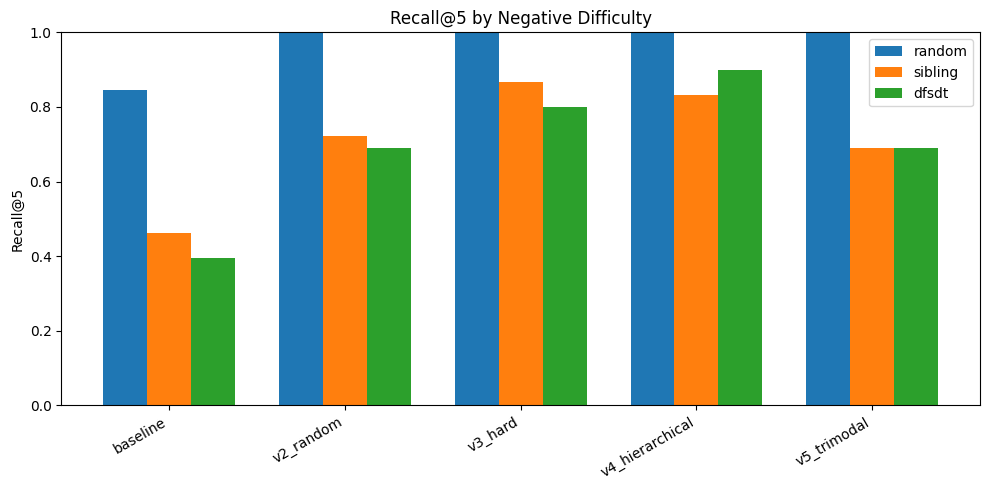

In [ ]:
# Performance degradation from random to DFSDT negatives (R@5)
print(f"{'Model':<25} {'R@5 random':>12} {'R@5 dfsdt':>12} {'Drop':>8} {'Drop %':>8}")
print('-' * 65)
for label in ['baseline'] + list(embeddings.keys()):
    r_rand = hn_results[label]['random']['recall@5']
    r_dfsdt = hn_results[label]['dfsdt']['recall@5']
    drop = r_rand - r_dfsdt
    drop_pct = drop / r_rand * 100 if r_rand > 0 else 0
    print(f"{label:<25} {r_rand:>12.4f} {r_dfsdt:>12.4f} {drop:>8.4f} {drop_pct:>7.1f}%")

# Grouped bar chart
fig, ax = plt.subplots(figsize=(10, 5))
model_labels = ['baseline'] + list(embeddings.keys())
x = np.arange(len(model_labels))
width = 0.25

for i, neg_type in enumerate(['random', 'sibling', 'dfsdt']):
    vals = [hn_results[m][neg_type]['recall@5'] for m in model_labels]
    ax.bar(x + i * width, vals, width, label=neg_type)

ax.set_ylabel('Recall@5')
ax.set_title('Recall@5 by Negative Difficulty')
ax.set_xticks(x + width)
ax.set_xticklabels(model_labels, rotation=30, ha='right')
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(PROJECT_DIR / 'ablation_negatives.png', dpi=150)
plt.show()

## 4. Qualitative Analysis

### 4a. Examples where fine-tuning fixed baseline failures

Find queries where the baseline missed at R@5 but the best fine-tuned model succeeds.

In [ ]:
# Pick the best fine-tuned model by full-corpus R@5
best_model = max(embeddings.keys(), key=lambda m: full_results[m]['recall@5'])
print(f'Best fine-tuned model: {best_model}\n')

baseline_sc = all_full_scores['baseline']
best_sc = all_full_scores[best_model]

# Cases where baseline R@5=0 but fine-tuned R@5>0
fixed = []
for i in range(len(evals)):
    if baseline_sc[i]['r@5'] == 0 and best_sc[i]['r@5'] > 0:
        fixed.append(i)

print(f'Fixed by fine-tuning: {len(fixed)} / {len(evals)} examples\n')
for rank, i in enumerate(fixed[:5], 1):
    ex = evals[i]
    print(f'--- Fixed #{rank} ---')
    print(f'Query: {ex["user_query"][:200]}')
    print(f'Expected: {ex["ground_truth_apis"][:3]}')
    baseline_top5 = [api_names[j] for j in baseline_sc[i]['top_k'][:5]]
    best_top5 = [api_names[j] for j in best_sc[i]['top_k'][:5]]
    print(f'Baseline top-5: {baseline_top5}')
    print(f'{best_model} top-5: {best_top5}\n')

Best fine-tuned model: v3_hard

Fixed by fine-tuning: 8 / 747 examples

--- Fixed #1 ---
Query: 
I'm planning a vacation to a foreign country and I need to exchange currency. Can you provide me with the current exchange rates for USD to EUR? Additionally, I would like to know the historical pric
Expected: ['coinmill_for_coinmill_currency', 'rates_for_currencyapi_net', 'get_coin_price_history_for_coinranking']
Baseline top-5: ['get_currency_for_tripadvisor', 'currency_exchange_rate_for_alpha_vantage', 'currency_exchange_rate_crypto_for_alpha_vantage', 'popular_rates_for_ziff', 'currencies_get_rate_for_investing_cryptocurrency_markets']
v3_hard top-5: ['dailyohlcv_for_bravenewcoin', 'assetticker_for_bravenewcoin', 'assetbyid_for_bravenewcoin', 'coins_search_for_investing_cryptocurrency_markets', 'asset_for_bravenewcoin']

--- Fixed #2 ---
Query: 
I want to surprise my sister with a playlist of her favorite songs. Can you fetch the comments for the songs in her favorite album on Deezer? A

### 4b. Remaining failure cases

Queries where even the best fine-tuned model fails at R@10.

In [ ]:
# Cases where all models fail at R@10
still_fail = []
for i in range(len(evals)):
    all_fail = all(all_full_scores[m][i]['r@10'] == 0 for m in all_full_scores)
    if all_fail:
        still_fail.append(i)

print(f'Still failing at R@10 across all models: {len(still_fail)} / {len(evals)}\n')
for rank, i in enumerate(still_fail[:5], 1):
    ex = evals[i]
    gt_cats = {lookup[n]['category'] for n in ex['ground_truth_apis'] if n in lookup}
    print(f'--- Failure #{rank} ---')
    print(f'Query: {ex["user_query"][:200]}')
    print(f'Expected: {ex["ground_truth_apis"][:3]}')
    print(f'Categories: {gt_cats}')
    best_top5 = [api_names[j] for j in best_sc[i]['top_k'][:5]]
    print(f'{best_model} top-5: {best_top5}\n')

Still failing at R@10 across all models: 2 / 747

--- Failure #1 ---
Query: 
I'm a music lover and I want to discover new artists. Could you please suggest some popular artists from the Billboard's Greatest of All Time Alternative Artists chart? Additionally, I would like to 
Expected: ['alternative_artists_for_billboard_api', 'artist_for_deezer', 'song_info_for_soundcloud']
Categories: {'Music'}
v3_hard top-5: ['get_artists_for_spotify', 'get_artists_for_spotify_data', 'artists_get_summary_for_shazam', 'artists_get_details_for_shazam', 'charts_track_for_shazam']

--- Failure #2 ---
Query: 
I'm a music enthusiast and I enjoy discovering new artists and songs. Could you provide me with a list of tracks from a specific genre, such as indie or alternative? Additionally, recommend an artist
Expected: ['switzerland_songs_for_billboard_api', 'colombia_songs_for_billboard_api', 'artists_get_details_for_shazam']
Categories: {'Music'}
v3_hard top-5: ['songs_list_artist_top_tracks_deprecated_for

### 4c. t-SNE Visualization

Visualize the embedding space before and after fine-tuning, colored by API category.

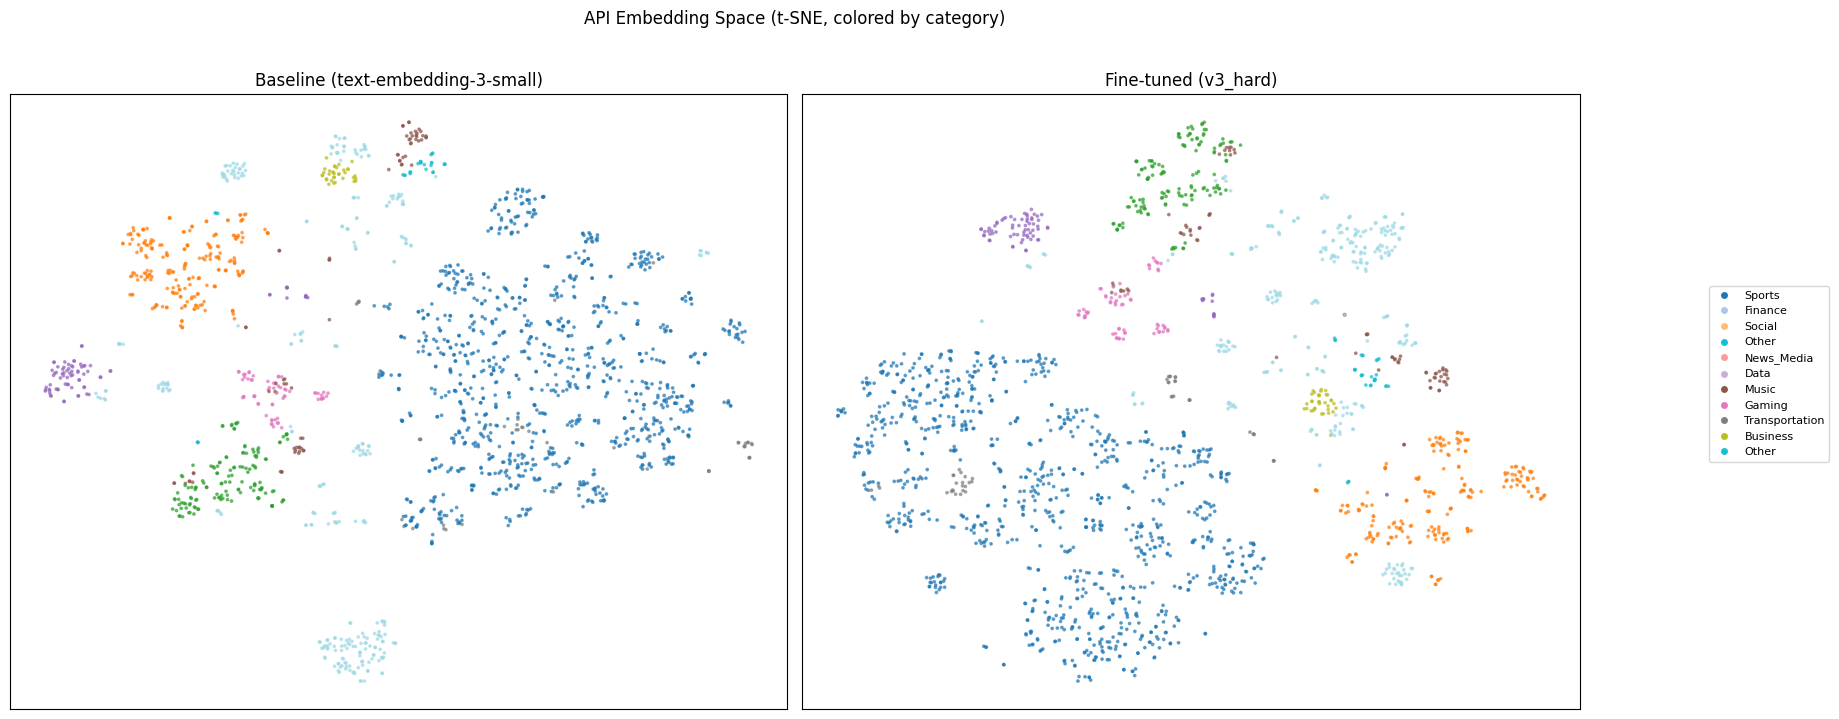

In [ ]:
from sklearn.manifold import TSNE

# Sample 2000 APIs for t-SNE (full corpus is too large)
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(corpus), size=min(2000, len(corpus)), replace=False)
sample_cats = [corpus[i]['category'] for i in sample_idx]

# Assign colors to top-10 categories, rest as "Other"
from collections import Counter
cat_counts = Counter(sample_cats)
top_cats = [c for c, _ in cat_counts.most_common(10)]
cat_labels = [c if c in top_cats else 'Other' for c in sample_cats]
unique_labels = top_cats + ['Other']
color_map = {c: i for i, c in enumerate(unique_labels)}
colors = [color_map[c] for c in cat_labels]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Baseline embeddings
tsne_base = TSNE(n_components=2, perplexity=30, random_state=42)
proj_base = tsne_base.fit_transform(baseline_corpus[sample_idx])
sc1 = axes[0].scatter(proj_base[:, 0], proj_base[:, 1], c=colors, cmap='tab20', s=3, alpha=0.6)
axes[0].set_title('Baseline (text-embedding-3-small)')
axes[0].set_xticks([])
axes[0].set_yticks([])

# Best fine-tuned embeddings
best_corpus = embeddings[best_model]['corpus']
tsne_ft = TSNE(n_components=2, perplexity=30, random_state=42)
proj_ft = tsne_ft.fit_transform(best_corpus[sample_idx].astype(np.float32))
sc2 = axes[1].scatter(proj_ft[:, 0], proj_ft[:, 1], c=colors, cmap='tab20', s=3, alpha=0.6)
axes[1].set_title(f'Fine-tuned ({best_model})')
axes[1].set_xticks([])
axes[1].set_yticks([])

# Shared legend
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=plt.cm.tab20(color_map[c] / len(unique_labels)), markersize=6, label=c[:25]) for c in unique_labels]
fig.legend(handles=handles, loc='center right', bbox_to_anchor=(1.15, 0.5), fontsize=8)
plt.suptitle('API Embedding Space (t-SNE, colored by category)', y=1.02)
plt.tight_layout()
plt.savefig(PROJECT_DIR / 'tsne_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Publication Figures

### 5a. Main results bar chart (full-corpus R@1, R@5, R@10)

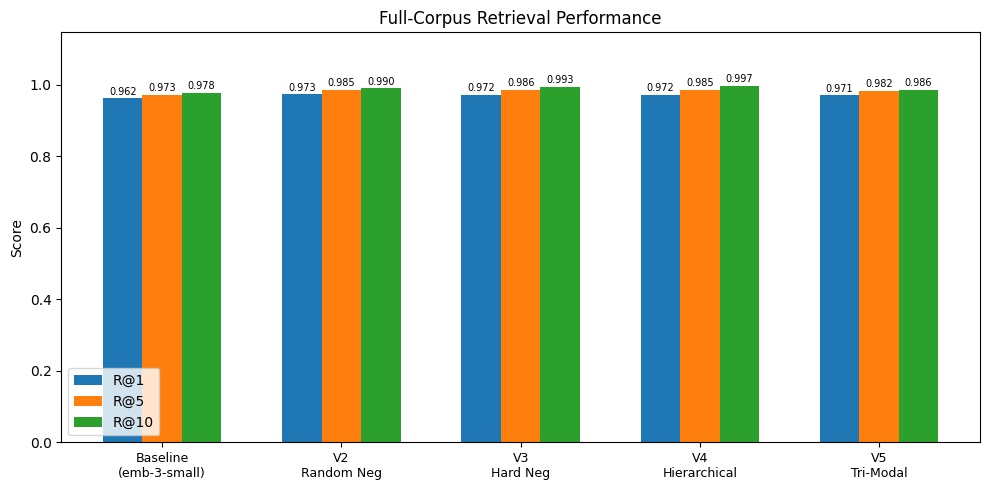

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
model_labels = ['baseline'] + list(embeddings.keys())
display_names = {
    'baseline': 'Baseline\n(emb-3-small)',
    'v2_random': 'V2\nRandom Neg',
    'v3_hard': 'V3\nHard Neg',
    'v4_hierarchical': 'V4\nHierarchical',
    'v5_trimodal': 'V5\nTri-Modal',
}
x = np.arange(len(model_labels))
width = 0.22

for i, metric in enumerate(['recall@1', 'recall@5', 'recall@10']):
    vals = [full_results[m][metric] for m in model_labels]
    bars = ax.bar(x + i * width, vals, width, label=metric.replace('recall@', 'R@'))
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7)

ax.set_ylabel('Score')
ax.set_title('Full-Corpus Retrieval Performance')
ax.set_xticks(x + width)
ax.set_xticklabels([display_names.get(m, m) for m in model_labels], fontsize=9)
ax.legend()
ax.set_ylim(0, max(full_results[m]['recall@10'] for m in model_labels) * 1.15)
plt.tight_layout()
plt.savefig(PROJECT_DIR / 'fig_full_corpus.png', dpi=200)
plt.show()

### 5b. Per-category improvement heatmap

Show R@5 improvement over baseline for each model across the hardest categories.

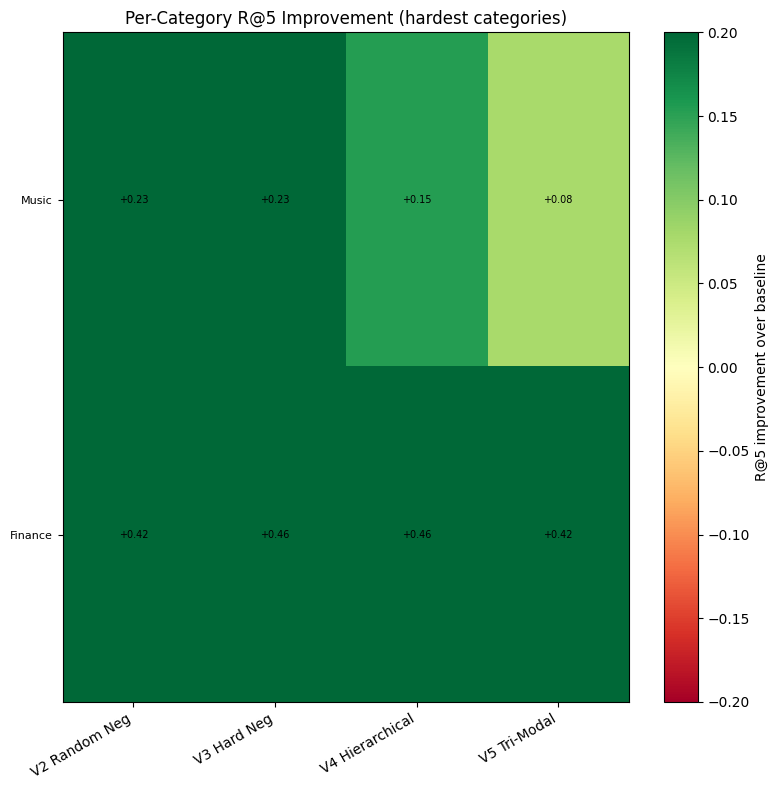

In [ ]:
# Per-category R@5 for each model
cat_model_scores = {}
for model_label in ['baseline'] + list(embeddings.keys()):
    scores = all_full_scores[model_label]
    cat_scores = defaultdict(list)
    for i, ex in enumerate(evals):
        cats = {lookup[n]['category'] for n in ex['ground_truth_apis'] if n in lookup}
        for cat in cats:
            cat_scores[cat].append(scores[i]['r@5'])
    cat_model_scores[model_label] = {cat: np.mean(v) for cat, v in cat_scores.items() if len(v) >= 5}

# Find hardest categories (lowest baseline R@5)
baseline_cat = cat_model_scores['baseline']
hard_cats = sorted(baseline_cat.items(), key=lambda x: x[1])[:15]
hard_cat_names = [c for c, _ in hard_cats]

# Build heatmap matrix: improvement over baseline
ft_models = list(embeddings.keys())
matrix = np.zeros((len(hard_cat_names), len(ft_models)))
for j, m in enumerate(ft_models):
    for i, cat in enumerate(hard_cat_names):
        bl = baseline_cat.get(cat, 0)
        ft = cat_model_scores[m].get(cat, 0)
        matrix[i, j] = ft - bl

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(matrix, cmap='RdYlGn', aspect='auto', vmin=-0.2, vmax=0.2)
ax.set_xticks(range(len(ft_models)))
ax.set_xticklabels([display_names.get(m, m).replace('\n', ' ') for m in ft_models], rotation=30, ha='right')
ax.set_yticks(range(len(hard_cat_names)))
ax.set_yticklabels([c[:30] for c in hard_cat_names], fontsize=8)
for i in range(len(hard_cat_names)):
    for j in range(len(ft_models)):
        ax.text(j, i, f'{matrix[i, j]:+.2f}', ha='center', va='center', fontsize=7)
plt.colorbar(im, label='R@5 improvement over baseline')
ax.set_title('Per-Category R@5 Improvement (hardest categories)')
plt.tight_layout()
plt.savefig(PROJECT_DIR / 'fig_category_heatmap.png', dpi=200)
plt.show()

## 6. Save All Results

In [ ]:
# Compute bootstrap CIs for the final results JSON
significance = {}
for label in embeddings:
    significance[label] = {}
    for metric in ['r@1', 'r@5', 'r@10', 'mrr']:
        diff, lo, hi, sig = bootstrap_ci(baseline_scores, all_full_scores[label], metric)
        significance[label][metric] = {'diff': diff, 'ci_lo': lo, 'ci_hi': hi, 'significant': sig == 'Yes'}

final_results = {
    'full_corpus': full_results,
    'hard_negative_ablation': hn_results,
    'significance_vs_baseline': significance,
    'qualitative': {
        'n_fixed_by_finetuning': len(fixed),
        'n_still_failing': len(still_fail),
        'best_model': best_model,
    },
}
with open(PROJECT_DIR / 'results_final.json', 'w') as f:
    json.dump(final_results, f, indent=2)
print('Saved results_final.json')

# Summary
print(f'\nBest model: {best_model}')
print(f'Full-corpus R@5: {full_results["baseline"]["recall@5"]:.4f} (baseline) -> {full_results[best_model]["recall@5"]:.4f} ({best_model})')
print(f'DFSDT R@5: {hn_results["baseline"]["dfsdt"]["recall@5"]:.4f} (baseline) -> {hn_results[best_model]["dfsdt"]["recall@5"]:.4f} ({best_model})')
print(f'Fixed {len(fixed)} baseline failures, {len(still_fail)} remain intractable')

Saved results_final.json

Best model: v3_hard
Full-corpus R@5: 0.9726 (baseline) -> 0.9862 (v3_hard)
DFSDT R@5: 0.3944 (baseline) -> 0.8000 (v3_hard)
Fixed 8 baseline failures, 2 remain intractable
